In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from matplotlib import colors
import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.stats import chi2_contingency
from statsmodels.tools.eval_measures import aic, bic
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import chi2_contingency
import seaborn as sns

In [193]:
df = pd.read_csv("ESS10.csv",sep=',', low_memory=False)

# filtering adults (18-65) who are more capible for employmnet

In [199]:
df = df[(df['agea'] >= 18) & (df['agea'] <= 65)]
print(f"Filtered dataset shape: {df.shape}")
print(f"Age range: {df['agea'].min()} to {df['agea'].max()}")

Filtered dataset shape: (27224, 618)
Age range: 18 to 65


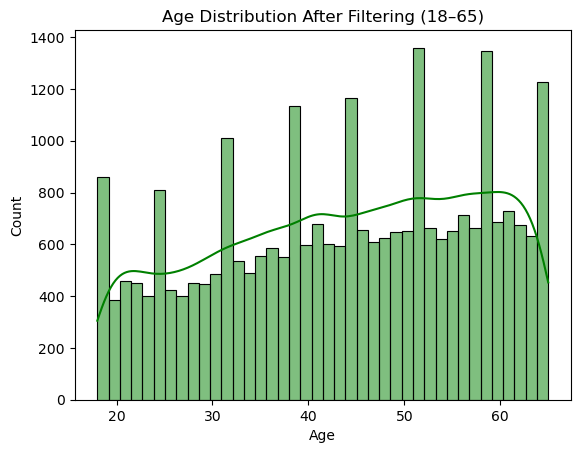

In [201]:
sns.histplot(df['agea'], bins=40, kde=True, color='green')
plt.title("Age Distribution After Filtering (18–65)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

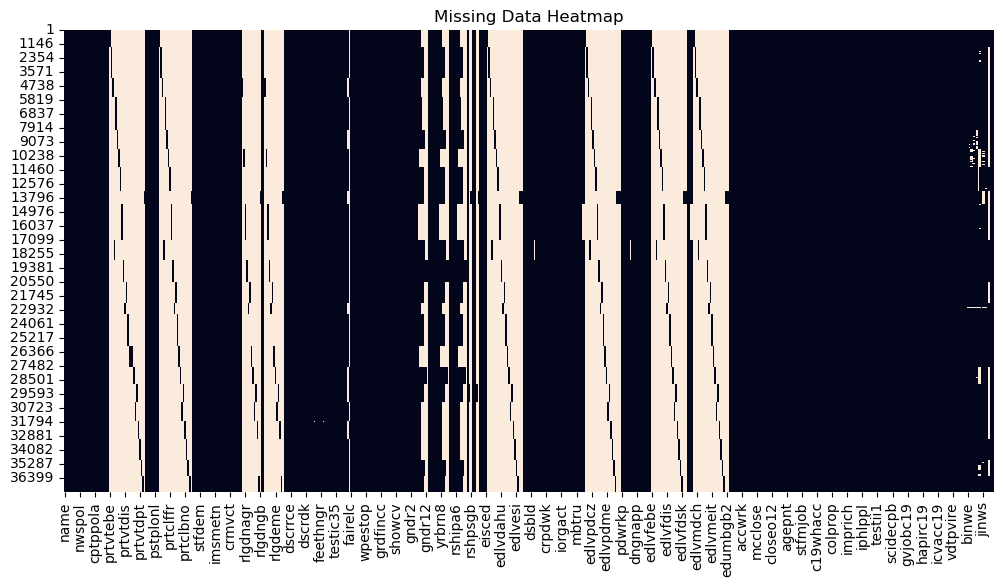

In [203]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [106]:
df.head()

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,vinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
1,ESS10e03_2,10,3.2,02.11.2023,10053,BE,1.047643,0.888635,0.718075,0.638107,...,2022-04-08 11:07:00,2022-04-08 11:10:00,2022-04-08 11:07:00,2022-04-08 11:10:00,54.0,2,2.0,0.000334,194,2206
2,ESS10e03_2,10,3.2,02.11.2023,10055,BE,1.087741,0.722811,0.718075,0.519033,...,2022-05-20 11:08:00,2022-05-20 11:10:00,2022-05-20 11:08:00,2022-05-20 11:10:00,77.0,1,2.0,0.000322,198,2114
3,ESS10e03_2,10,3.2,02.11.2023,10062,BE,0.909910,1.005565,0.718075,0.722072,...,2022-05-22 13:58:00,2022-05-22 13:59:00,2022-05-22 13:58:00,2022-05-22 13:59:00,55.0,1,1.0,0.000385,150,2645
4,ESS10e03_2,10,3.2,02.11.2023,10064,BE,0.918949,0.638705,0.718075,0.458639,...,2022-05-18 11:44:00,2022-05-18 11:45:00,2022-05-18 11:44:00,2022-05-18 11:45:00,55.0,1,1.0,0.000381,149,2313
5,ESS10e03_2,10,3.2,02.11.2023,10077,BE,0.913740,0.706166,0.718075,0.507080,...,2022-03-17 18:24:00,2022-03-17 18:25:00,2022-03-17 18:24:00,2022-03-17 18:25:00,68.0,1,1.0,0.000383,136,2212


In [138]:
columns_list = df.columns.to_list()

In [253]:
df_copy = df.copy()

columns = ["pdwrk","agea","gndr","agepnt","ttminpnt","acchome","chldo12","hhlio12","marsts","domicil","hinctnta",
           "health","hlthhmp","ipadvnt", "hincfel","sclact","ipcrtiv","ipmodst","hincsrca","mnactp"]

df_train = df[columns].copy()

In [213]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27224 entries, 1 to 37610
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pdwrk     27224 non-null  int64
 1   agea      27224 non-null  int64
 2   gndr      27224 non-null  int64
 3   agepnt    27224 non-null  int64
 4   ttminpnt  27224 non-null  int64
 5   acchome   27224 non-null  int64
 6   chldo12   27224 non-null  int64
 7   hhlio12   27224 non-null  int64
 8   marsts    27224 non-null  int64
 9   domicil   27224 non-null  int64
 10  hinctnta  27224 non-null  int64
 11  health    27224 non-null  int64
 12  hlthhmp   27224 non-null  int64
 13  ipadvnt   27224 non-null  int64
 14  hincfel   27224 non-null  int64
 15  sclact    27224 non-null  int64
 16  ipcrtiv   27224 non-null  int64
 17  ipmodst   27224 non-null  int64
 18  hincsrca  27224 non-null  int64
 19  mnactp    27224 non-null  int64
dtypes: int64(20)
memory usage: 4.4 MB


# Missing data in percentage

In [215]:
missing_pct = df_train.isnull().mean() * 100
print(missing_pct)

pdwrk       0.0
agea        0.0
gndr        0.0
agepnt      0.0
ttminpnt    0.0
acchome     0.0
chldo12     0.0
hhlio12     0.0
marsts      0.0
domicil     0.0
hinctnta    0.0
health      0.0
hlthhmp     0.0
ipadvnt     0.0
hincfel     0.0
sclact      0.0
ipcrtiv     0.0
ipmodst     0.0
hincsrca    0.0
mnactp      0.0
dtype: float64


In [217]:
df_train = df_train.dropna()
print(f"Original shape: {df_train.shape}")
print(f"After dropna:   {df_train.shape}")

Original shape: (27224, 20)
After dropna:   (27224, 20)


In [223]:
unique_cut = 0.10 
freq_cut = 0.95   

near_zero_vars = []

for col in df_train.columns:
    counts = df_train[col].value_counts(dropna=False)
    unique_perc = len(counts) / len(df)
    top_freq_perc = counts.iloc[0] / len(df)
    if unique_perc <= unique_cut and top_freq_perc >= freq_cut:
        near_zero_vars.append(col)

print("Near zero variance variables:", near_zero_vars)

Near zero variance variables: ['mnactp']


In [225]:
df_train = df_train.drop(columns=near_zero_vars)
print(f"Original shape: {df_train.shape}")
print(f"After dropping near zero variance: {df_train.shape}")

Original shape: (27224, 19)
After dropping near zero variance: (27224, 19)


### We identified near-zero variance features where more than 95% of the values were the same, making them uninformative for predictive modeling. These were removed to reduce noise and overfitting risk. But we got none columns 

In [255]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan  # Avoid division by zero
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

cat_vars = list(df_train.columns)
print(cat_vars)

['pdwrk', 'agea', 'gndr', 'agepnt', 'ttminpnt', 'acchome', 'chldo12', 'hhlio12', 'marsts', 'domicil', 'hinctnta', 'health', 'hlthhmp', 'ipadvnt', 'hincfel', 'sclact', 'ipcrtiv', 'ipmodst', 'hincsrca', 'mnactp']


In [257]:
matrix = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)

for col1 in cat_vars:
    for col2 in cat_vars:
        if col1 == col2:
            matrix.loc[col1, col2] = 1.0  # Perfect association with itself
        else:
            matrix.loc[col1, col2] = cramers_v(df_train[col1], df_train[col2])

print("\nCramér’s V Matrix:")
print(matrix.round(3))


Cramér’s V Matrix:
          pdwrk   agea   gndr  agepnt  ttminpnt  acchome  chldo12  hhlio12  \
pdwrk     1.000  0.396  0.103   0.286     0.255    0.122    0.081    0.099   
agea      0.396  1.000  0.040   0.190     0.107    0.181    0.228    0.339   
gndr      0.103  0.040  1.000   0.052     0.101    0.024    0.091    0.093   
agepnt    0.286  0.190  0.052   1.000     0.149    0.189    0.214    0.289   
ttminpnt  0.255  0.107  0.101   0.149     1.000    0.154    0.153    0.174   
acchome   0.122  0.181  0.024   0.189     0.154    1.000    0.081    0.088   
chldo12   0.081  0.228  0.091   0.214     0.153    0.081    1.000    0.582   
hhlio12   0.099  0.339  0.093   0.289     0.174    0.088    0.582    1.000   
marsts    0.125  0.209  0.121   0.186     0.145    0.116    0.215    0.260   
domicil   0.052  0.053  0.036   0.096     0.157    0.091    0.133    0.116   
hinctnta  0.343  0.099  0.066   0.135     0.176    0.183    0.174    0.193   
health    0.204  0.138  0.050   0.128     0.

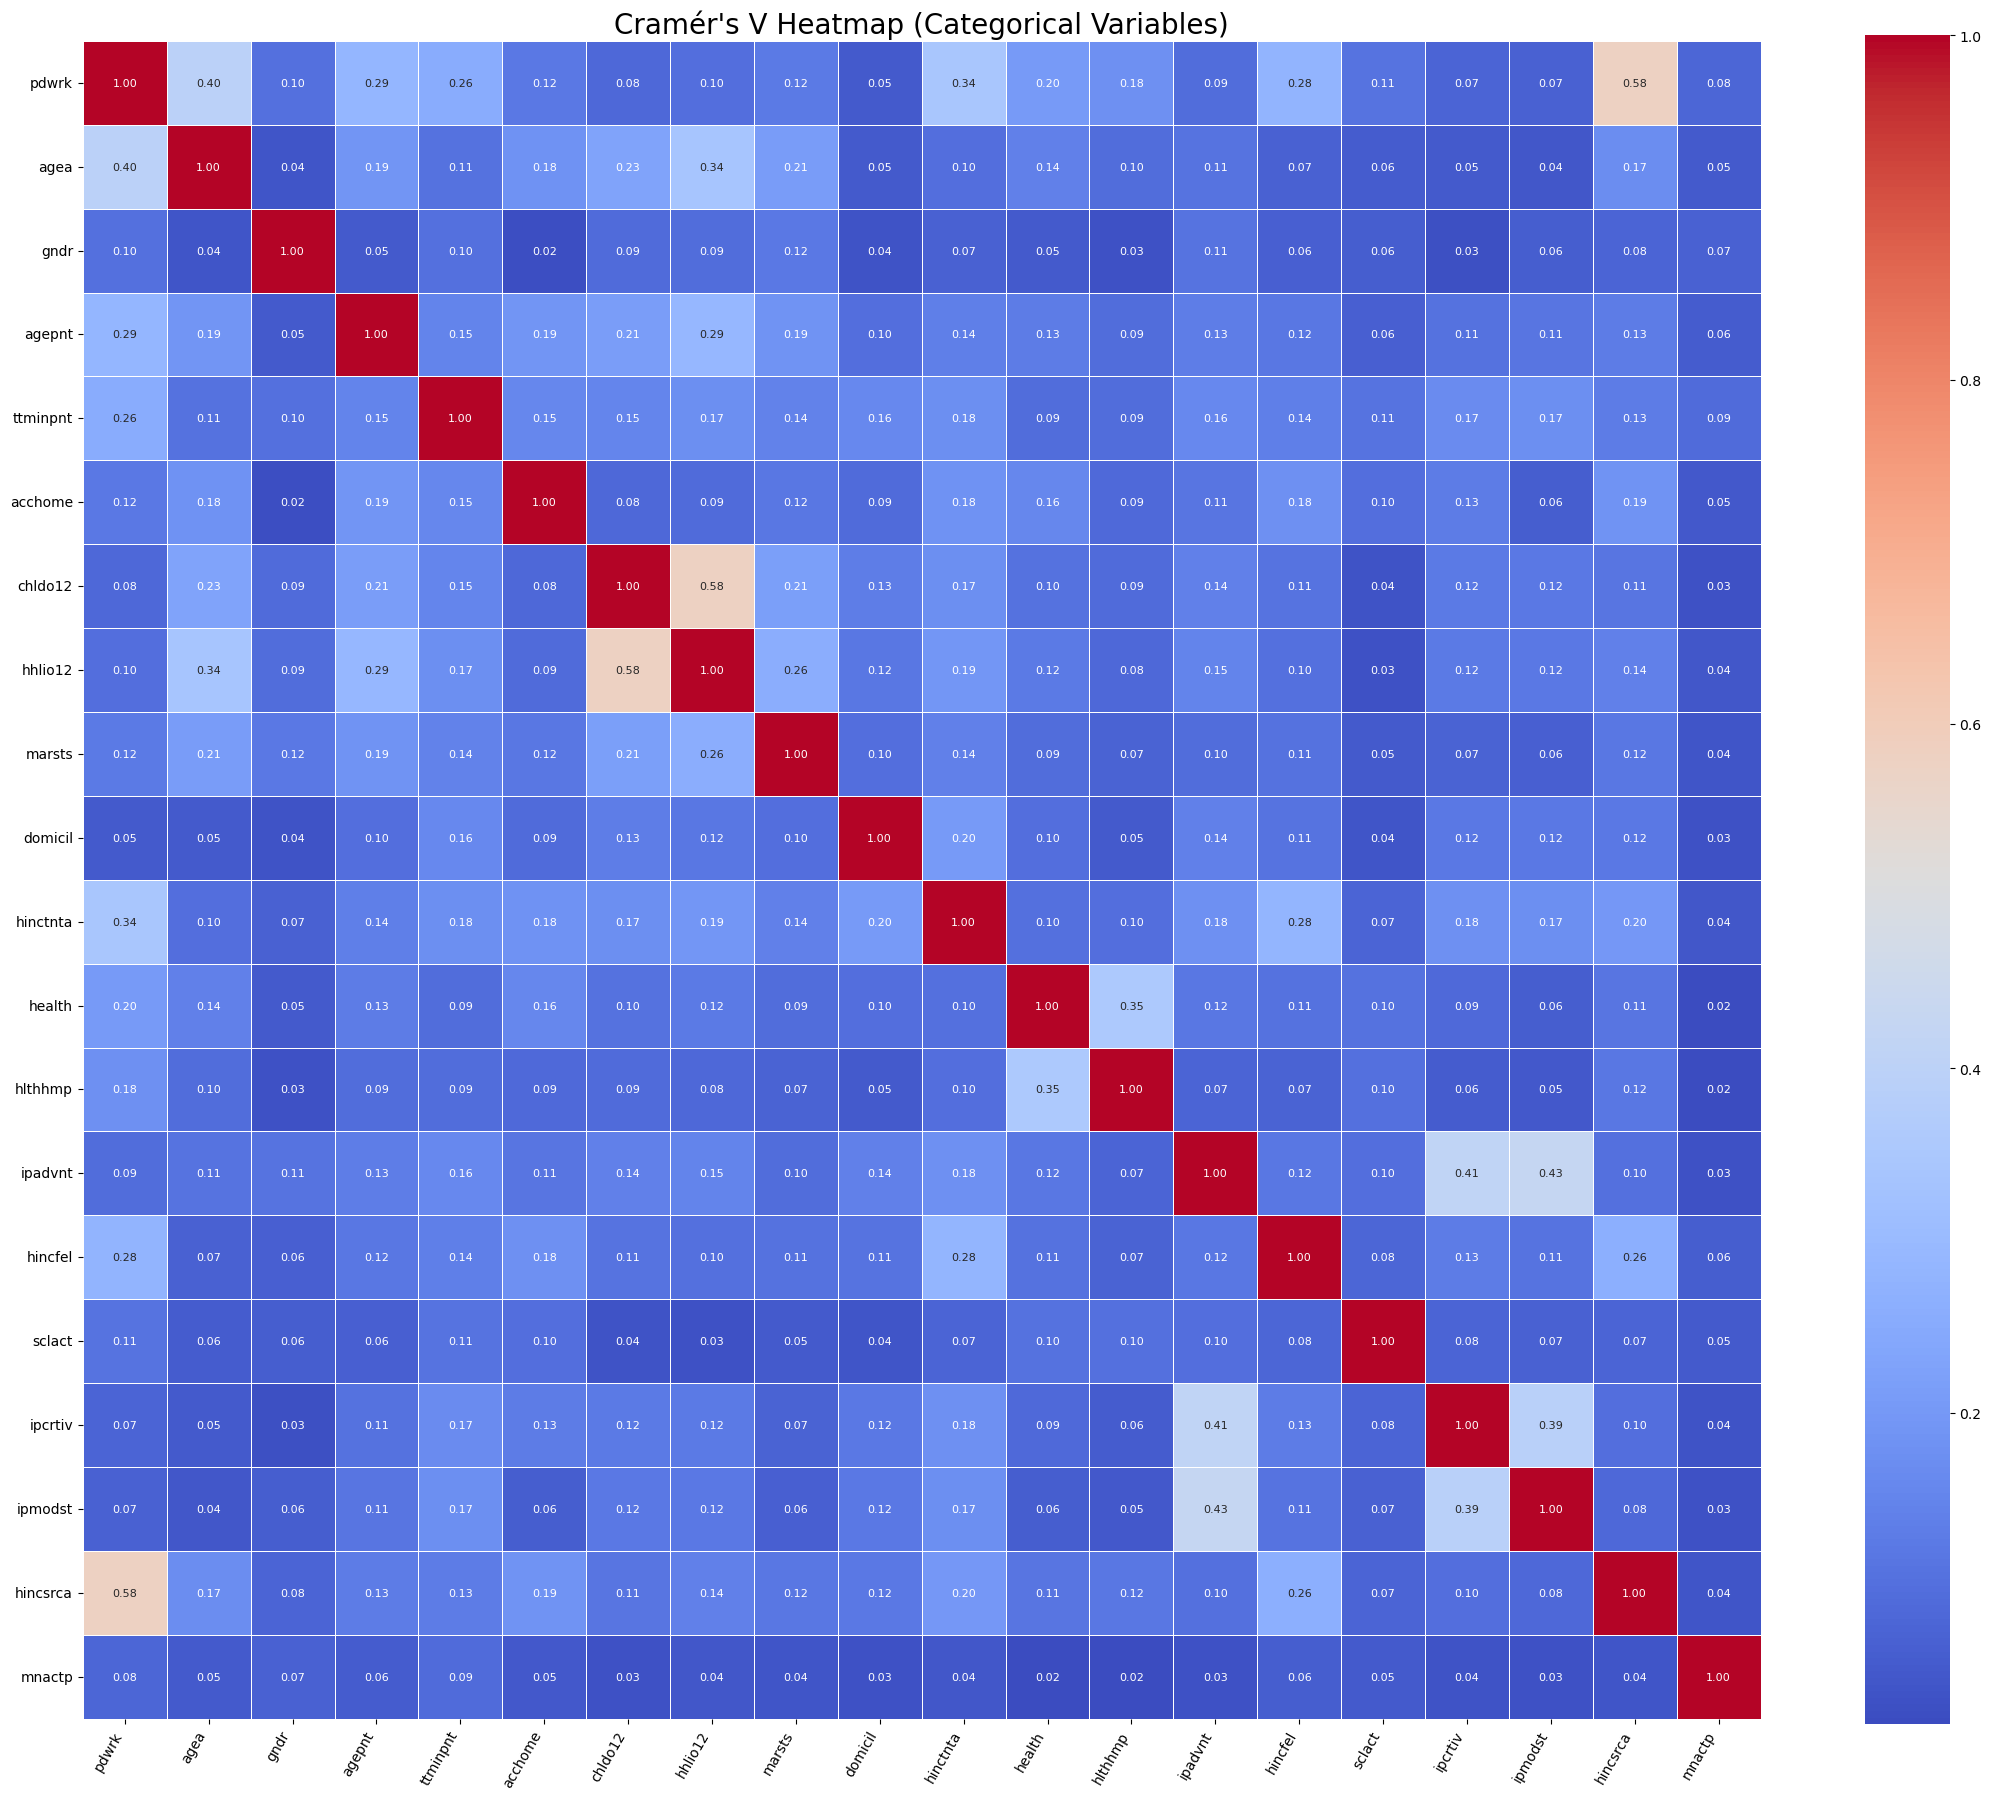

In [259]:
plt.figure(figsize=(22, 18))  # Much larger
sns.heatmap(
    matrix.round(3).astype(float),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    linewidths=.5,
    annot_kws={"size":8}  # Smaller annotation text
)
plt.title("Cramér's V Heatmap (Categorical Variables)", fontsize=20)
plt.xticks(rotation=60, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

- Before modeling, we encoded categorical variables using binary mapping (e.g., gender) or one-hot encoding (e.g., marital status, health levels) to transform them into a numerical format suitable for machine learning.

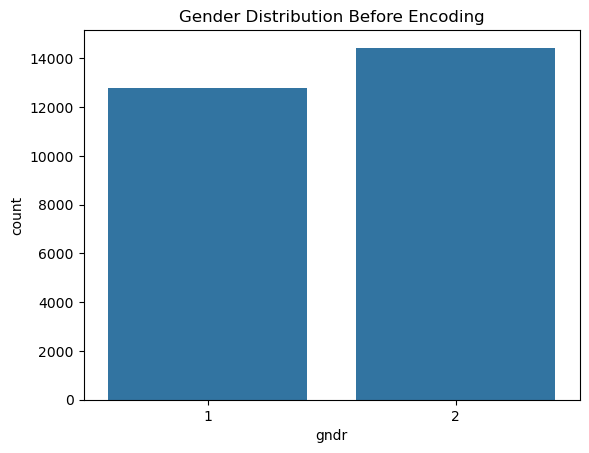

In [235]:
sns.countplot(data=df_train, x='gndr')
plt.title("Gender Distribution Before Encoding")
plt.show()

In [237]:
df_train['gndr'] = df_train['gndr'].replace({9: np.nan})
# Encode as binary: 0 = Male, 1 = Female
df_train['gndr'] = df_train['gndr'].map({1: 0, 2: 1})

df_train['hhlio12'] = df_train['hhlio12'].replace({6: np.nan, 7: np.nan, 8: np.nan, 9: np.nan})
# Encode as binary: 1 = Yes, 0 = No
df_train['hhlio12'] = df_train['hhlio12'].map({1: 1, 2: 0})

df_train['marsts'] = df_train['marsts'].replace({66: np.nan, 77: np.nan, 88: np.nan, 99: np.nan})
# Then treat as categorical for modeling (do not treat as numeric!)
df_train['marsts'] = df_train['marsts'].astype('category')
df_train = pd.get_dummies(df_train, columns=['marsts'], drop_first=True)

df_train['domicil'] = df_train['domicil'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train['domicil'] = df_train['domicil'].astype('category')
# For modeling, use one-hot encoding:
df_train = pd.get_dummies(df_train, columns=['domicil'], drop_first=True)

df_train['hinctnta'] = df_train['hinctnta'].replace({77: np.nan, 88: np.nan, 99: np.nan})
# Optionally, convert to numeric (if not already)
df_train['hinctnta'] = pd.to_numeric(df_train['hinctnta'], errors='coerce')
df_train = pd.get_dummies(df_train, columns=['hinctnta'], drop_first=True)

df_train['health'] = df_train['health'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['health'], drop_first=True)
# This will create dummies health_2, health_3, health_4, health_5 (1 is reference)

df_train['hlthhmp'] = df_train['hlthhmp'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['hlthhmp'], drop_first=True)
# This will give dummies: hlthhmp_2, hlthhmp_3 (reference = "a lot")

df_train['ipadvnt'] = df_train['ipadvnt'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['ipadvnt'], drop_first=True)
# Dummies: ipadvnt_2, ipadvnt_3, ..., ipadvnt_6 (1 is reference)


df_train['hincfel'] = df_train['hincfel'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['hincfel'], drop_first=True)
# Dummies: hincfel_2, hincfel_3, hincfel_4 (1 is reference)


df_train['sclact'] = df_train['sclact'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['sclact'], drop_first=True)
# Dummies: sclact_2, sclact_3, sclact_4, sclact_5 (reference = 1)


df_train['ipcrtiv'] = df_train['ipcrtiv'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['ipcrtiv'], drop_first=True)
# Dummies: ipcrtiv_2, ipcrtiv_3, ..., ipcrtiv_6 (1 is reference)

df_train['ipmodst'] = df_train['ipmodst'].replace({7: np.nan, 8: np.nan, 9: np.nan})
df_train = pd.get_dummies(df_train, columns=['ipmodst'], drop_first=True)
# Dummies: ipmodst_2, ipmodst_3, ..., ipmodst_6 (1 is reference)


df_train['hincsrca'] = df_train['hincsrca'].replace({77: np.nan, 88: np.nan, 99: np.nan})
df_train['hincsrca'] = df_train['hincsrca'].astype('category')
# For modeling, use one-hot encoding (dummies):
# df = pd.get_dummies(df, columns=['hincsrca'], drop_first=True)


--- 
Some variables contained placeholder values (e.g., 777, 8888). These were replaced with NaN, and rows with missing values in these key variables were removed to ensure data quality. 

----

In [239]:
fake_codes = {
    'agepnt':   [666, 777, 888, 999],
    'ttminpnt': [6666, 7777, 8888, 9999],
    'chldo12':  [77, 88, 99]
}

# Replace each fake code with np.nan
for var, codes in fake_codes.items():
    df_train[var] = df_train[var].replace(codes, np.nan)

# Drop rows with missing in ANY of these numeric variables
df_train = df_train.dropna(subset=fake_codes.keys())

# (Optional) Make sure columns are numeric
for var in fake_codes.keys():
    df_train[var] = pd.to_numeric(df_train[var], errors='coerce')

# Show result
print(df_train[fake_codes.keys()].describe())


             agepnt      ttminpnt       chldo12
count  14749.000000  14749.000000  14749.000000
mean      68.982982    107.108957      0.830904
std       11.027823    265.861090      1.098124
min       32.000000      0.000000      0.000000
25%       61.000000     10.000000      0.000000
50%       69.000000     25.000000      0.000000
75%       77.000000     80.000000      2.000000
max       90.000000   5760.000000      6.000000


In [241]:
missing_pct = df_train.isnull().mean() * 100
print(missing_pct)

pdwrk             0.000000
agea              0.000000
gndr              0.000000
agepnt            0.000000
ttminpnt          0.000000
acchome           0.000000
chldo12           0.000000
hhlio12          55.705472
hincsrca          0.555970
marsts_2.0        0.000000
marsts_3.0        0.000000
marsts_4.0        0.000000
marsts_5.0        0.000000
marsts_6.0        0.000000
domicil_2.0       0.000000
domicil_3.0       0.000000
domicil_4.0       0.000000
domicil_5.0       0.000000
hinctnta_2.0      0.000000
hinctnta_3.0      0.000000
hinctnta_4.0      0.000000
hinctnta_5.0      0.000000
hinctnta_6.0      0.000000
hinctnta_7.0      0.000000
hinctnta_8.0      0.000000
hinctnta_9.0      0.000000
hinctnta_10.0     0.000000
health_2.0        0.000000
health_3.0        0.000000
health_4.0        0.000000
health_5.0        0.000000
hlthhmp_2.0       0.000000
hlthhmp_3.0       0.000000
ipadvnt_2.0       0.000000
ipadvnt_3.0       0.000000
ipadvnt_4.0       0.000000
ipadvnt_5.0       0.000000
i

In [243]:
print("Before dropna:", df_train.shape)
df_train = df_train.dropna()
print("After dropna:", df_train.shape)

Before dropna: (14749, 55)
After dropna: (6500, 55)


In [245]:
print(df_train.isnull().sum().sum())  # Should print 0

0


In [247]:
print("\n===== FINAL DF INFO =====")
print(df_train.info())
print("\nFirst few rows:")
print(df_train.head())


===== FINAL DF INFO =====
<class 'pandas.core.frame.DataFrame'>
Index: 6500 entries, 2 to 37604
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   pdwrk          6500 non-null   int64   
 1   agea           6500 non-null   int64   
 2   gndr           6500 non-null   int64   
 3   agepnt         6500 non-null   float64 
 4   ttminpnt       6500 non-null   float64 
 5   acchome        6500 non-null   int64   
 6   chldo12        6500 non-null   float64 
 7   hhlio12        6500 non-null   float64 
 8   hincsrca       6500 non-null   category
 9   marsts_2.0     6500 non-null   bool    
 10  marsts_3.0     6500 non-null   bool    
 11  marsts_4.0     6500 non-null   bool    
 12  marsts_5.0     6500 non-null   bool    
 13  marsts_6.0     6500 non-null   bool    
 14  domicil_2.0    6500 non-null   bool    
 15  domicil_3.0    6500 non-null   bool    
 16  domicil_4.0    6500 non-null   bool    
 17  domicil_5.

In [261]:
df_train.to_csv('df_train_clean_1010.csv', index=False)